# Projet ML - Depistage du diabete
Ce notebook construit, compare et valide des modeles de classification sur le dataset Pima Indians Diabetes.

## Objectifs
- Preparer les donnees sans fuite d'information.
- Comparer Regression Logistique et Random Forest.
- Optimiser un seuil de decision oriente recall (depistage).
- Evaluer des criteres d'acceptation clinique.
- Exporter un artefact pret pour Streamlit (modele + seuil).

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 1) Chargement des donnees

In [2]:
print(os.getcwd())
df = pd.read_csv("diabetes.csv")
df.head(), df.shape

c:\Users\MUNYON\Downloads\Programmation\Machine Learning


(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0            6      148             72             35        0  33.6   
 1            1       85             66             29        0  26.6   
 2            8      183             64              0        0  23.3   
 3            1       89             66             23       94  28.1   
 4            0      137             40             35      168  43.1   
 
    DiabetesPedigreeFunction  Age  Outcome  
 0                     0.627   50        1  
 1                     0.351   31        0  
 2                     0.672   32        1  
 3                     0.167   21        0  
 4                     2.288   33        1  ,
 (768, 9))

## 2) Controle qualite des donnees
Certaines colonnes contiennent des 0 qui representent des valeurs manquantes sur le plan clinique.

In [3]:
df.describe()
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3) Separation des variables
- `X`: variables explicatives
- `y`: variable cible (`Outcome`)

In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## 4) Split train/test
On conserve la proportion des classes via `stratify=y`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

## 5) Preprocessing
Pipeline numerique:
- remplacement des 0 cliniquement invalides par `NaN`,
- imputation mediane,
- standardisation.

In [6]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Les 0 sont traites comme valeurs manquantes pour ces variables
X_train[zero_as_missing] = X_train[zero_as_missing].replace(0, np.nan)
X_test[zero_as_missing] = X_test[zero_as_missing].replace(0, np.nan)

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

## 6) Baseline - Regression Logistique
Modele lineaire de reference pour la classification binaire.

In [7]:
logreg_model = Pipeline(steps=[
("preprocessor", preprocessor),
("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

## 7) Evaluation du baseline
On suit Accuracy, Precision, Recall, F1 et ROC-AUC, puis la matrice de confusion.

In [8]:
y_pred = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred))
print("\nRapport:\n", classification_report(y_test, y_pred))

Accuracy : 0.7077922077922078
Precision: 0.6
Recall : 0.5
F1-score : 0.5454545454545454
ROC-AUC : 0.812962962962963

Matrice de confusion:
 [[82 18]
 [27 27]]

Rapport:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## 8) Comparaison avec Random Forest
Random Forest capte mieux les relations non lineaires et permet un meilleur compromis en depistage.

In [9]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                random_state=42,
                class_weight="balanced_subsample",
                min_samples_leaf=2,
                max_depth=8,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest (seuil 0.5) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_rf))
print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred_rf))

=== Random Forest (seuil 0.5) ===
Accuracy : 0.7532467532467533
Precision: 0.6333333333333333
Recall : 0.7037037037037037
F1-score : 0.6666666666666666
ROC-AUC : 0.8288888888888889

Matrice de confusion:
 [[78 22]
 [16 38]]


## 9) Optimisation du seuil (orientation depistage)
Le seuil est choisi sur un jeu de validation interne pour maximiser le rappel (recall) sous contrainte metier.

In [10]:
# 1) Split interne train/validation pour choisir le seuil sans fuite de données
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

rf_for_threshold = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        max_depth=8
    ))
])

rf_for_threshold.fit(X_tr, y_tr)
val_proba = rf_for_threshold.predict_proba(X_val)[:, 1]

# 2) Recherche du meilleur seuil selon une contrainte de recall minimale
target_recall = 0.80
candidate_thresholds = np.arange(0.20, 0.61, 0.01)

rows = []
for thr in candidate_thresholds:
    y_val_pred_thr = (val_proba >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "precision": precision_score(y_val, y_val_pred_thr, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_thr, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_thr, zero_division=0)
    })

threshold_table = pd.DataFrame(rows)
eligible = threshold_table[threshold_table["recall"] >= target_recall]

if len(eligible) > 0:
    # Parmi les seuils qui respectent le recall cible, on maximise le F1
    best_row = eligible.sort_values(["f1", "precision"], ascending=False).iloc[0]
else:
    # Si aucun seuil n'atteint le recall cible, on prend le meilleur recall
    best_row = threshold_table.sort_values(["recall", "f1"], ascending=False).iloc[0]

best_threshold = float(best_row["threshold"])
print("Seuil choisi:", round(best_threshold, 2))
print("Perf validation au seuil choisi:")
print(best_row)

# 3) Ré-entraînement sur tout X_train puis évaluation finale sur X_test
rf_model.fit(X_train, y_train)
y_proba_rf_test = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf_best = (y_proba_rf_test >= best_threshold).astype(int)

print("\n=== Random Forest (seuil optimisé) ===")
print("Threshold:", round(best_threshold, 2))
print("Accuracy :", accuracy_score(y_test, y_pred_rf_best))
print("Precision:", precision_score(y_test, y_pred_rf_best))
print("Recall :", recall_score(y_test, y_pred_rf_best))
print("F1-score :", f1_score(y_test, y_pred_rf_best))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_rf_test))
print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred_rf_best))

print("\nTop 10 seuils (validation) :")
display(threshold_table.sort_values(["f1", "recall"], ascending=False).head(10))

Seuil choisi: 0.4
Perf validation au seuil choisi:
threshold    0.400000
precision    0.676471
recall       0.851852
f1           0.754098
Name: 20, dtype: float64

=== Random Forest (seuil optimisé) ===
Threshold: 0.4
Accuracy : 0.7337662337662337
Precision: 0.5866666666666667
Recall : 0.8148148148148148
F1-score : 0.6821705426356589
ROC-AUC : 0.8288888888888889

Matrice de confusion:
 [[69 31]
 [10 44]]

Top 10 seuils (validation) :


,threshold,precision,recall,f1
20,0.40,0.676471,0.851852,0.754098
21,0.41,0.671642,0.833333,0.743802
19,0.39,0.657143,0.851852,0.741935
17,0.37,0.643836,0.870370,0.740157
18,0.38,0.647887,0.851852,0.736000
22,0.42,0.666667,0.814815,0.733333
12,0.32,0.602410,0.925926,0.729927
15,0.35,0.626667,0.870370,0.728682
16,0.36,0.626667,0.870370,0.728682
14,0.34,0.615385,0.888889,0.727273


## 10) Criteres d'acceptation clinique
Decision automatique `ACCEPTABLE` / `A AMELIORER` selon des cibles minimales (recall, precision, ROC-AUC).

In [11]:
# Evaluation clinique automatique (sur le test set, au seuil optimisé)
if "y_proba_rf_test" not in globals():
    y_proba_rf_test = rf_model.predict_proba(X_test)[:, 1]

if "y_pred_rf_best" not in globals():
    y_pred_rf_best = (y_proba_rf_test >= best_threshold).astype(int)

test_metrics = {
    "recall": recall_score(y_test, y_pred_rf_best),
    "precision": precision_score(y_test, y_pred_rf_best),
    "f1": f1_score(y_test, y_pred_rf_best),
    "roc_auc": roc_auc_score(y_test, y_proba_rf_test),
    "accuracy": accuracy_score(y_test, y_pred_rf_best)
}

# Seuils minimaux pour un scénario de dépistage
clinical_targets = {
    "recall": 0.80,
    "precision": 0.55,
    "roc_auc": 0.80
}

checks = {
    "recall_ok": test_metrics["recall"] >= clinical_targets["recall"],
    "precision_ok": test_metrics["precision"] >= clinical_targets["precision"],
    "roc_auc_ok": test_metrics["roc_auc"] >= clinical_targets["roc_auc"]
}

is_acceptable = all(checks.values())
status = "ACCEPTABLE" if is_acceptable else "A AMELIORER"

summary = pd.DataFrame([
    {
        "metric": "recall",
        "value": round(test_metrics["recall"], 3),
        "target": clinical_targets["recall"],
        "ok": checks["recall_ok"]
    },
    {
        "metric": "precision",
        "value": round(test_metrics["precision"], 3),
        "target": clinical_targets["precision"],
        "ok": checks["precision_ok"]
    },
    {
        "metric": "roc_auc",
        "value": round(test_metrics["roc_auc"], 3),
        "target": clinical_targets["roc_auc"],
        "ok": checks["roc_auc_ok"]
    }
])

print("=== Décision clinique du modèle Random Forest ===")
print("Statut:", status)
print("Seuil de décision utilisé:", round(best_threshold, 2))
print("\nMétriques complètes:", {k: round(v, 3) for k, v in test_metrics.items()})
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred_rf_best))

display(summary)

=== Décision clinique du modèle Random Forest ===
Statut: ACCEPTABLE
Seuil de décision utilisé: 0.4

Métriques complètes: {'recall': 0.815, 'precision': 0.587, 'f1': 0.682, 'roc_auc': 0.829, 'accuracy': 0.734}

Matrice de confusion:
[[69 31]
 [10 44]]


,metric,value,target,ok
0,recall,0.815,0.80,True
1,precision,0.587,0.55,True
2,roc_auc,0.829,0.80,True


## 11) Validation croisee
Estimation de robustesse via `StratifiedKFold` et score ROC-AUC.

ROC-AUC CV (LogReg): 0.8303878406708595 +/- 0.02228758281308102
ROC-AUC CV (RfModel): 0.8321649196366178 +/- 0.021772522487207194


<Axes: ylabel='Count'>

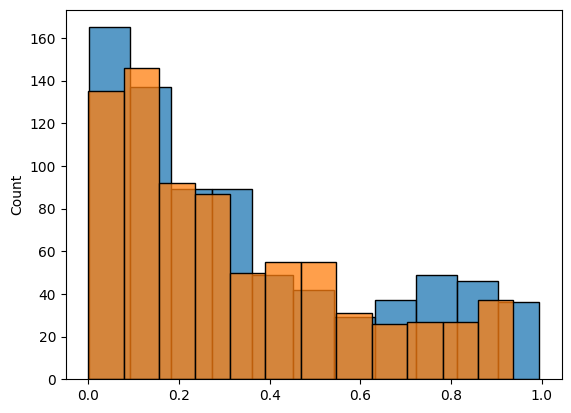

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(logreg_model, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC CV (LogReg):", auc_scores.mean(), "+/-", auc_scores.std())

auc_scores2 = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC CV (RfModel):", auc_scores2.mean(), "+/-", auc_scores2.std())

y_hat_proba = logreg_model.predict_proba(X)[:,1]
y_hat_proba2 = rf_model.predict_proba(X)[:,1]
import seaborn as sns
sns.histplot(y_hat_proba)
sns.histplot(y_hat_proba2)


## 12) Export du modele
Sauvegarde d'un artefact complet: modele Random Forest + seuil optimise.

In [13]:
import joblib

artifacts = {
    "model": rf_model,
    "threshold": best_threshold
}
joblib.dump(artifacts, "modele_diabete_random_forest.pkl")
print("Modèle sauvegardé: modele_diabete_random_forest.pkl")

Modèle sauvegardé: modele_diabete_random_forest.pkl


## 13) Test sur un nouveau patient
Ordre attendu des colonnes: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.

In [14]:
new_patient = pd.DataFrame([{
"Pregnancies": 2,
"Glucose": 120,
"BloodPressure": 80,
"SkinThickness": 25,
"Insulin": 100,
"BMI": 31.2,
"DiabetesPedigreeFunction": 0.45,
"Age": 35
}])

# Probabilité prédite par Random Forest
proba_rf = rf_model.predict_proba(new_patient)[:, 1][0]
pred_rf = int(proba_rf >= best_threshold)

print("Seuil utilisé:", round(best_threshold, 2))
print("Probabilité diabète (RF):", round(proba_rf, 3))
print("Classe prédite RF (1=diabète, 0=non):", pred_rf)

Seuil utilisé: 0.4
Probabilité diabète (RF): 0.426
Classe prédite RF (1=diabète, 0=non): 1
